---
date: "2026-07-20"
date-modified: last-modified
format:
  html:
    toc: true
---

# Markov's Inequality

## 1\. Statement of Markov's Inequality

::: {#thm-markovs-inequality}
## Markov's Inequality
Let $X$ be any [Random Variable](random-variables.ipynb) such that its absolute [Expectation](expectation.ipynb) $E|X|$ exists, and let $a > 0$ be any strictly positive real threshold. Then:
$$
\mathbb{P}(|X| \geq a) \leq \frac{E|X|}{a}
$$
*(Note: If $Y$ is a non-negative random variable taking values $Y \geq 0$ almost surely, this inequality is commonly stated as $\mathbb{P}(Y \geq a) \leq \frac{E(Y)}{a}$. Applying this form directly to the non-negative random variable $|X|$ yields $\mathbb{P}(|X| \geq a) \leq \frac{E|X|}{a}$.)*
:::

## 2\. Proof of Markov's Inequality

::: {.callout-tip collapse="true"}
## Proof of Markov's Inequality (Using Indicator Functions)
Let $I_{\{|X| \geq a\}}$ be the [Indicator Random Variable](indicator-rv.ipynb) for the event that $|X| \geq a$, defined point-wise as:
$$
I_{\{|X| \geq a\}} = \begin{cases} 
1 & \text{if } |X| \geq a \\
0 & \text{if } |X| < a 
\end{cases}
$$
Notice that because $a > 0$ and $|X| \geq 0$, for every possible outcome $\omega$ in the sample space, the following point-wise inequality holds:
$$
a \cdot I_{\{|X| \geq a\}} \leq |X|
$$
*(Why does this hold? If $|X| \geq a$, the indicator is $1$, so the left side is $a \cdot 1 = a \leq |X|$. If $|X| < a$, the indicator is $0$, so the left side is $a \cdot 0 = 0 \leq |X|$.)*

Because the inequality $a \cdot I_{\{|X| \geq a\}} \leq |X|$ holds for all outcomes, we can take the [Expectation](expectation.ipynb) of both sides while preserving the order of the inequality by monotonicity:
$$
E\left[a \cdot I_{\{|X| \geq a\}}\right] \leq E|X|
$$
By linearity of expectation, and using the fundamental identity that the expected value of an indicator function equals the [Probability](probability.ipynb) of its underlying event ($E[I_A] = \mathbb{P}(A)$):
$$
\begin{aligned}
a \cdot E\left[I_{\{|X| \geq a\}}\right] &\leq E|X| \\
a \cdot \mathbb{P}(|X| \geq a) &\leq E|X|
\end{aligned}
$$
Since $a > 0$, we can divide both sides by $a$ without flipping the inequality sign to obtain Markov's inequality:
$$
\mathbb{P}(|X| \geq a) \leq \frac{E|X|}{a}
$$
$\blacksquare$
:::

## 3\. Example and Intuition
Markov's inequality provides a universal upper bound on the tail probability of any random variable based solely on its first absolute moment, requiring absolutely no knowledge about the exact shape of the underlying distribution.

**Example:**
Suppose a factory produces precision rods whose absolute deviation from the target length has an average of $E|X| = 2\text{ mm}$. What is the maximum possible probability that a randomly chosen rod deviates by $a = 10\text{ mm}$ or more?

Applying **Markov's Inequality** directly:
$$
\mathbb{P}(|X| \geq 10) \leq \frac{E|X|}{10} = \frac{2}{10} = 0.20
$$
Thus, regardless of whether the deviation distribution is exponential, heavy-tailed, or discrete, **at most $20\%$** of the rods can deviate by $10\text{ mm}$ or more from the nominal specification.

::: {.callout-note}
## Intuition: The Cost of Heavy Tails
Imagine distributing a total mass of $E|X|$ across the positive number line. To place as much probability mass as possible at or beyond the threshold $a$, the most efficient strategy is placing all of that tail mass exactly at $a$ (since placing mass further out at values greater than $a$ uses up the available mean budget faster). If probability mass $p$ is placed at $a$, its contribution to the mean is $p \cdot a$. Since the total mean budget is $E|X|$, we must have $p \cdot a \leq E|X|$, which directly forces $p \leq \frac{E|X|}{a}$.
:::

Furthermore, Markov's inequality serves as the theoretical stepping stone used to prove [Chebyshev's Inequality](chebyshevs-inequality.ipynb).

In [1]:
import warnings
warnings.filterwarnings('ignore')

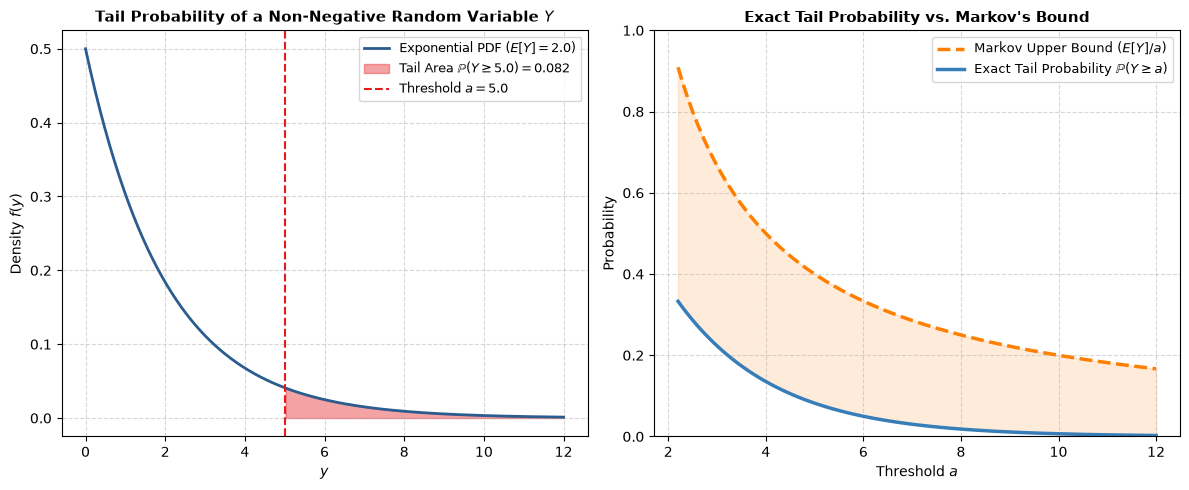

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# Define a non-negative Exponential distribution with mean E[Y] = 2.0 (lambda = 0.5)
mean_Y = 2.0
lam = 1.0 / mean_Y

# Thresholds to compare exact tail probability vs Markov bound
a_values = np.linspace(2.2, 12.0, 100)
exact_tail_prob = np.exp(-lam * a_values)  # P(Y >= a) for exponential distribution
markov_bound = mean_Y / a_values          # E[Y] / a

# Visualization
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Plot 1: PDF showing tail area above threshold a = 5.0
y = np.linspace(0, 12, 400)
pdf = lam * np.exp(-lam * y)
a_example = 5.0

ax1.plot(y, pdf, color="#2b5c8f", linewidth=2, label="Exponential PDF ($E[Y] = 2.0$)")
ax1.fill_between(y[y >= a_example], pdf[y >= a_example], color="#e41a1c", alpha=0.4, label=f"Tail Area $\mathbb{{P}}(Y \geq {a_example}) = {np.exp(-lam*a_example):.3f}$")
ax1.axvline(a_example, color="#e41a1c", linestyle="--", linewidth=1.5, label=f"Threshold $a = {a_example}$")
ax1.set_title("Tail Probability of a Non-Negative Random Variable $Y$", fontsize=11, fontweight="bold")
ax1.set_xlabel("$y$", fontsize=10)
ax1.set_ylabel("Density $f(y)$", fontsize=10)
ax1.grid(True, linestyle="--", alpha=0.5)
ax1.legend(loc="upper right", fontsize=9)

# Plot 2: Exact probability vs Markov Bound across different thresholds
ax2.plot(a_values, markov_bound, color="#ff7f00", linewidth=2.5, linestyle="--", label="Markov Upper Bound ($E[Y]/a$)")
ax2.plot(a_values, exact_tail_prob, color="#377eb8", linewidth=2.5, label="Exact Tail Probability $\mathbb{P}(Y \geq a)$")
ax2.set_title("Exact Tail Probability vs. Markov's Bound", fontsize=11, fontweight="bold")
ax2.set_xlabel("Threshold $a$", fontsize=10)
ax2.set_ylabel("Probability", fontsize=10)
ax2.set_ylim(0, 1.0)
ax2.grid(True, linestyle="--", alpha=0.5)
ax2.legend(loc="upper right", fontsize=9.5)

# Highlight that the bound strictly envelopes the exact probability
ax2.fill_between(a_values, exact_tail_prob, markov_bound, color="#ff7f00", alpha=0.15, label="Bound Slack")

plt.tight_layout()
plt.show()